In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")

print("Path to dataset files:", path)

Path to dataset files: /Users/ducnguyen/.cache/kagglehub/datasets/nikhil1e9/loan-default/versions/2


In [2]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "loan_default.csv"))

print(df.shape)
df.head()

(255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [4]:
print(df.isnull().sum())

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


All rows do not have any null values.

In [5]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
corr_to_default = (
    df.corr(numeric_only=True)["Default"]
      .drop("Default")
      .sort_values(key=abs, ascending=False)
)
print(corr_to_default)

Age              -0.167783
InterestRate      0.131273
Income           -0.099119
MonthsEmployed   -0.097374
LoanAmount        0.086659
CreditScore      -0.034166
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
Name: Default, dtype: float64


In [8]:
cat_cols = ["Education", "EmploymentType", "MaritalStatus", "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"]
for c in cat_cols:
    default_rate = (
        df.groupby(c)["Default"]
          .mean()
          .sort_values(ascending=False)
    )
    print(default_rate)
    print(" ")

Education
High School    0.128789
Bachelor's     0.121011
Master's       0.108717
PhD            0.105860
Name: Default, dtype: float64
 
EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64
 
MaritalStatus
Divorced    0.125328
Single      0.119124
Married     0.103972
Name: Default, dtype: float64
 
HasMortgage
No     0.123451
Yes    0.108806
Name: Default, dtype: float64
 
HasDependents
No     0.127244
Yes    0.105024
Name: Default, dtype: float64
 
LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64
 
HasCoSigner
No     0.128661
Yes    0.103601
Name: Default, dtype: float64
 


None of the features have strong correlations to the default. This dataset will require using DecisionTree and SVM for better prediciton as they are suitable for these kinds of things.

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
features = ["Age", "InterestRate", "Income", "MonthsEmployed", "LoanAmount"]
X = df[features]
y = df["Default"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
print(X_train.shape, X_test.shape)

(204277, 5) (51070, 5)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score

In [14]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0. , 0.01,-0. ,-0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age','InterestRate','Income','MonthsEmployed','LoanAmount']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.2555
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [15]:
lr_probability = linreg.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_probability)
print("Linear Regression MSE: ", lr_mse)


Linear Regression MSE:  0.0949153532813462


Choosing the 5 numerical features that have the most correlations to Default, the LG model produces 0.0949 MSE score

In [16]:
lr_probability_binary = (lr_probability >= 0.5).astype(int)

print("Linear Regression Accuracy: ", accuracy_score(y_test, lr_probability_binary))
print("Linear Regression ROC-AUC: ", roc_auc_score(y_test, lr_probability))

Linear Regression Accuracy:  0.8838652829449775
Linear Regression ROC-AUC:  0.7391367056245071


Rounding the probablity to binary values (yes - 1 or no - 0), the accruacy is around 0.8839 while the ROC-AU is 0.739

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
svm = make_pipeline(StandardScaler(), LinearSVC(random_state=42))
svm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Age','InterestRate','Income','MonthsEmployed','LoanAmount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [19]:
svm_pred = svm.predict(X_test)
svm_scores = svm.decision_function(X_test)

In [20]:
print("SVM Accuracy: ", accuracy_score(y_test, svm_pred))
print("SVM ROC-AUC: ", roc_auc_score(y_test, svm_scores))

SVM Accuracy:  0.8838652829449775
SVM ROC-AUC:  0.7390701135157518


SVM Accuracy is around 0.8839 while ROC-AUC is 0.7391

In [21]:
print(confusion_matrix(y_test, svm_pred))

[[45139     0]
 [ 5931     0]]


With confusion matrix, SVM predicts zero defaults.

In [22]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45139
           1       0.00      0.00      0.00      5931

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



/Users/ducnguyen/Desktop/AIT506/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ducnguyen/Desktop/AIT506/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ducnguyen/Desktop/AIT506/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [24]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [25]:
tree_pred = tree.predict(X_test)
tree_probability = tree.predict_proba(X_test)[:, 1]

In [26]:
tree_mse = mean_squared_error(y_test, tree_probability)
print("Decision MSE: ", tree_mse)

Decision MSE:  0.09524364339910157


In [27]:
print("Tree Accuracy: ", accuracy_score(y_test, tree_pred))
print("Tree ROC-AUC: ", roc_auc_score(y_test, tree_probability))

Tree Accuracy:  0.8838652829449775
Tree ROC-AUC:  0.7074576800668195


Tree Accuracy is around 0.8839 while ROC-AUC is 0.7075

In [28]:
print(confusion_matrix(y_test, tree_pred))

[[45139     0]
 [ 5931     0]]


Decision tree is also predicting zero default here.

In [29]:
import matplotlib.pyplot as plt

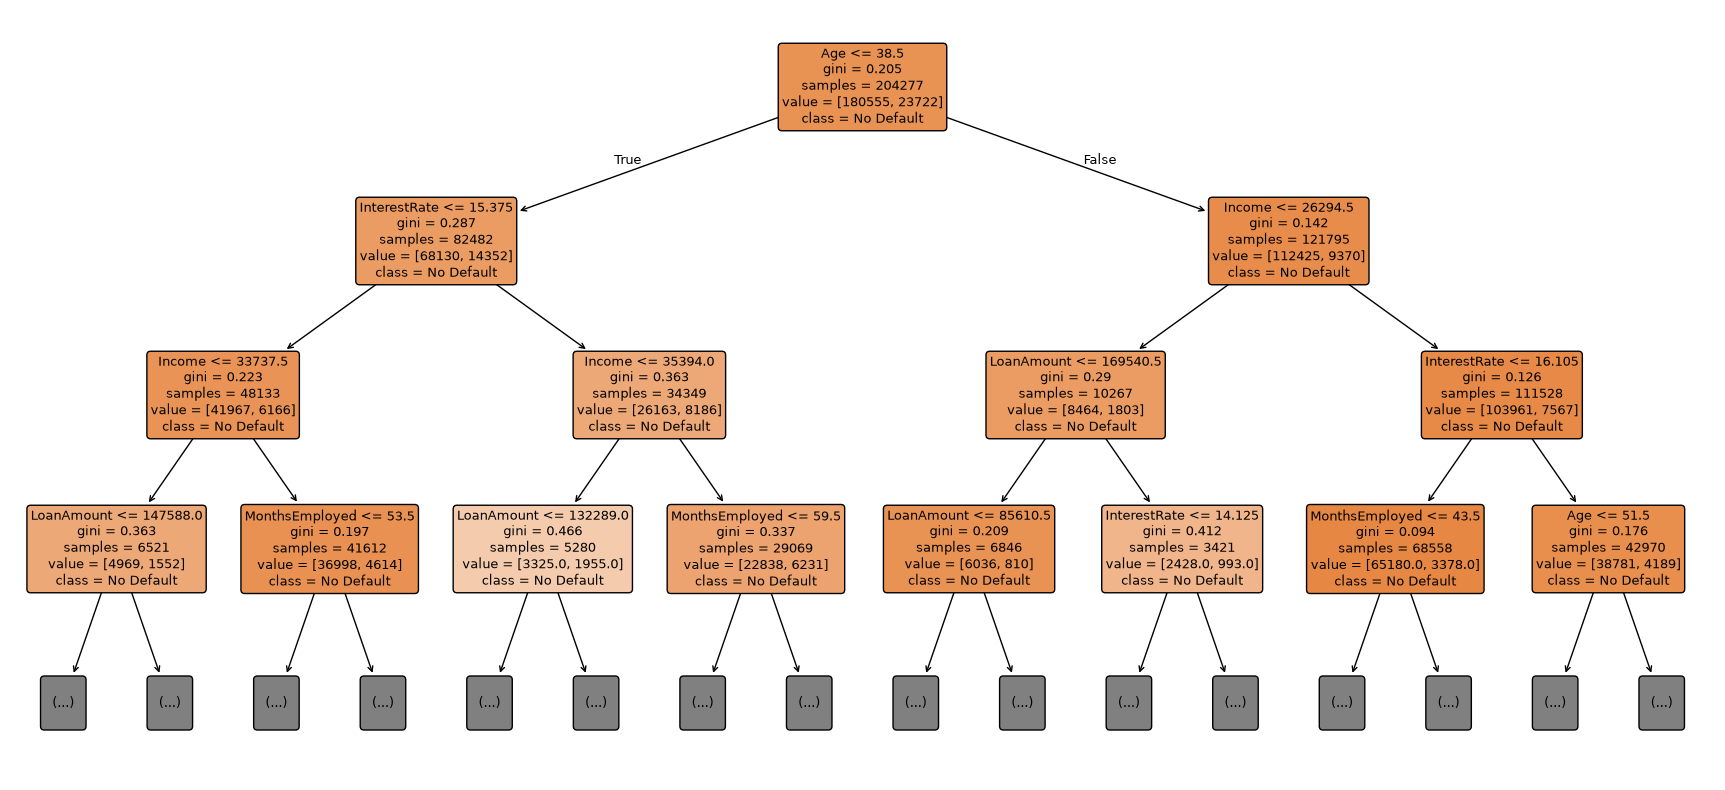

In [30]:
plt.figure(figsize=(22, 10))
plot_tree(tree, feature_names=features, class_names=["No Default", "Default"], filled=True, rounded=True, fontsize=9, max_depth=3)
plt.show()

In [31]:
importances = pd.Series(tree.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Age               0.340207
InterestRate      0.223527
Income            0.213646
LoanAmount        0.139069
MonthsEmployed    0.083551
dtype: float64


With the graph, we can see how the trees are going through multiple yes/no questions to classify and predict the probability of default. Age holds 34% importance while InterestRate and Income come after (22% and 21%). LoanAmount and MonthsEmployed are only at 14% and 8%.

In [32]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "SVM", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, lr_probability_binary), accuracy_score(y_test, svm_pred), accuracy_score(y_test, tree_pred)],
    "ROC-AUC": [roc_auc_score(y_test, lr_probability), roc_auc_score(y_test, svm_scores), roc_auc_score(y_test, tree_probability)],
    "MSE": [lr_mse, None, tree_mse],
})
print(results)

               Model  Accuracy   ROC-AUC       MSE
0  Linear Regression  0.883865  0.739137  0.094915
1                SVM  0.883865  0.739070       NaN
2      Decision Tree  0.883865  0.707458  0.095244


All the models have similar peformances due to imbalanced dataset. We will tweak the models after this.

In [33]:
svm_balanced = make_pipeline(StandardScaler(), LinearSVC(random_state=42, class_weight="balanced"))
svm_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Age','InterestRate','Income','MonthsEmployed','LoanAmount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [34]:
svm_pred_balanced = svm_balanced.predict(X_test)
svm_scores_balanced = svm_balanced.decision_function(X_test)

In [35]:
print("SVM Accuracy: ", accuracy_score(y_test, svm_pred_balanced))
print("SVM ROC-AUC: ", roc_auc_score(y_test, svm_scores_balanced))

SVM Accuracy:  0.6635989817897004
SVM ROC-AUC:  0.7393504144482852


In [36]:
print(confusion_matrix(y_test, svm_pred_balanced))

[[29760 15379]
 [ 1801  4130]]


In [37]:
tree_balanced = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
tree_balanced.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [38]:
tree_pred_balanced = tree_balanced.predict(X_test)
tree_probability_balanced = tree_balanced.predict_proba(X_test)[:, 1]

In [39]:
tree_mse_balanced = mean_squared_error(y_test, tree_probability_balanced)
print("Decision MSE: ", tree_mse_balanced)

Decision MSE:  0.21745653772718398


In [40]:
print("Tree Accuracy: ", accuracy_score(y_test, tree_pred_balanced))
print("Tree ROC-AUC: ", roc_auc_score(y_test, tree_probability_balanced))

Tree Accuracy:  0.6428039945173292
Tree ROC-AUC:  0.7089957082640952


In [41]:
print(confusion_matrix(y_test, tree_pred_balanced))

[[28828 16311]
 [ 1931  4000]]


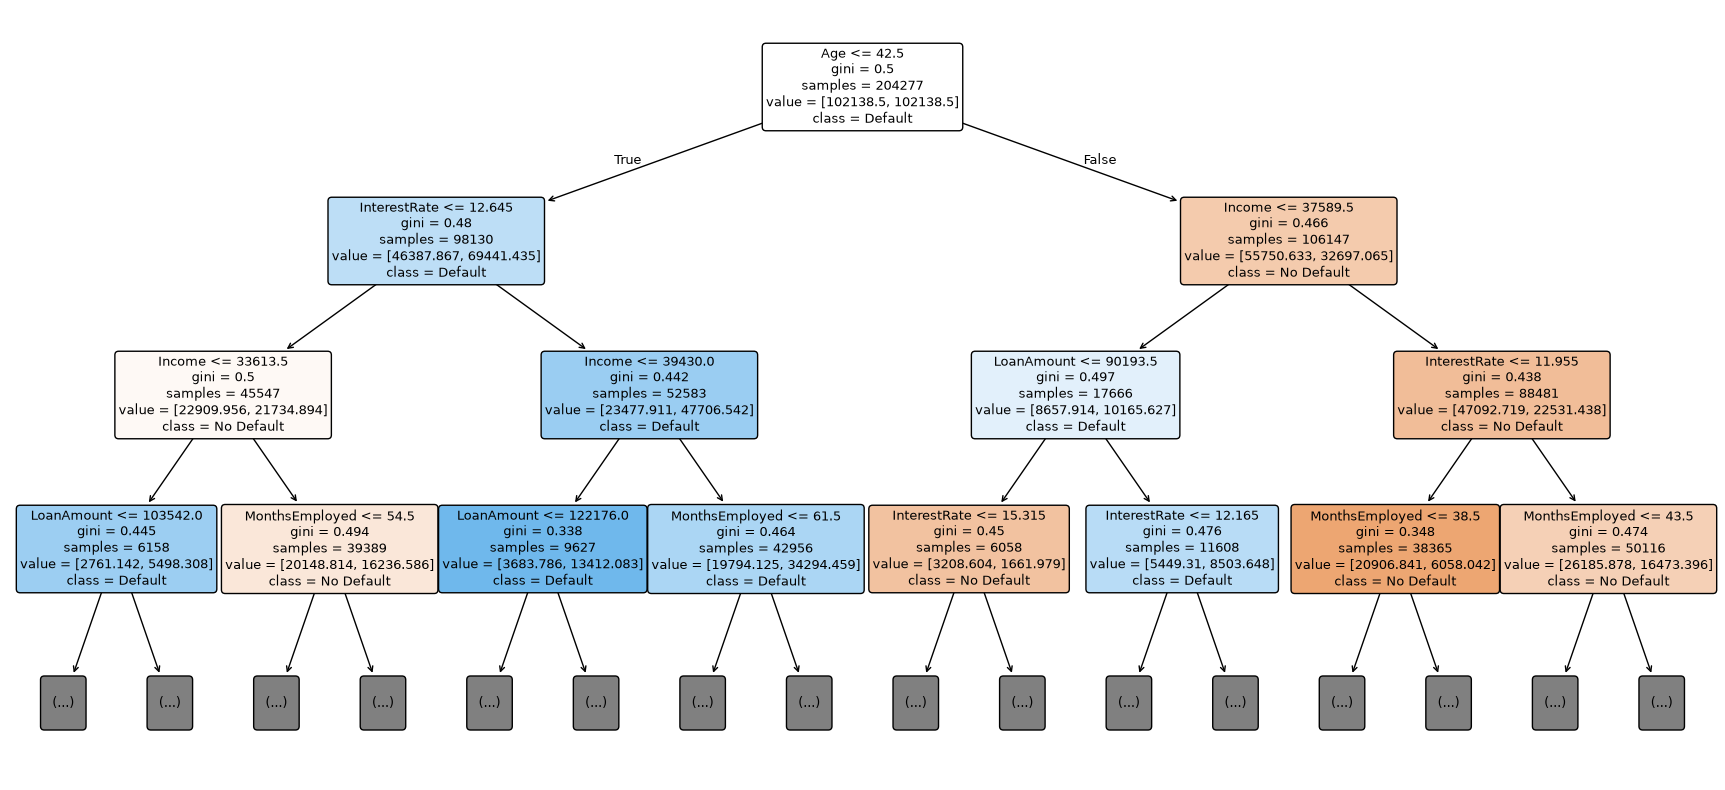

In [42]:
plt.figure(figsize=(22, 10))
plot_tree(tree_balanced, feature_names=features, class_names=["No Default", "Default"], filled=True, rounded=True, fontsize=9, max_depth=3)
plt.show()

In [43]:
importances = pd.Series(tree_balanced.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

Age               0.396721
InterestRate      0.225450
Income            0.196534
MonthsEmployed    0.109532
LoanAmount        0.071762
dtype: float64


Age increases in importance. InterestRate stays mostly the same, but Income, MonthsEmployed, and LoanAmount have a drop.

In [44]:
lr_probability_binary_balanced = (lr_probability >= 0.116).astype(int)

Since around 11.6% of the loan defaults, we should adjust the base rate to be 0.116 instead of 50-50.

In [45]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "SVM", "Decision Tree"],
    "Accuracy": [accuracy_score(y_test, lr_probability_binary_balanced), accuracy_score(y_test, svm_pred_balanced), accuracy_score(y_test, tree_pred_balanced)],
    "ROC-AUC": [roc_auc_score(y_test, lr_probability), roc_auc_score(y_test, svm_scores_balanced), roc_auc_score(y_test, tree_probability_balanced)],
    "MSE": [lr_mse, None, tree_mse_balanced],
})
print(results)

               Model  Accuracy   ROC-AUC       MSE
0  Linear Regression  0.564049  0.739137  0.094915
1                SVM  0.663599  0.739350       NaN
2      Decision Tree  0.642804  0.708996  0.217457


After balanced the model (due to only 11.6% of the rows are defaults), SVM performs the better than Linear Regression due to its higher accuracy score. Decision Tree shows how importance the features are in the prediciton though.